In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

# Set style for plots
sns.set_theme(style="whitegrid")

In [26]:
# Load the dataset
df = pd.read_csv('./diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [27]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [28]:
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"{col} has {df[col].isnull().sum()} missing values.")

race has 2273 missing values.
weight has 98569 missing values.
payer_code has 40256 missing values.
medical_specialty has 49949 missing values.
diag_1 has 21 missing values.
diag_2 has 358 missing values.
diag_3 has 1423 missing values.
max_glu_serum has 96420 missing values.
A1Cresult has 84748 missing values.


C:\Users\Lokesh Shrestha\AppData\Local\Temp\ipykernel_4100\3703005454.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted', palette='viridis')


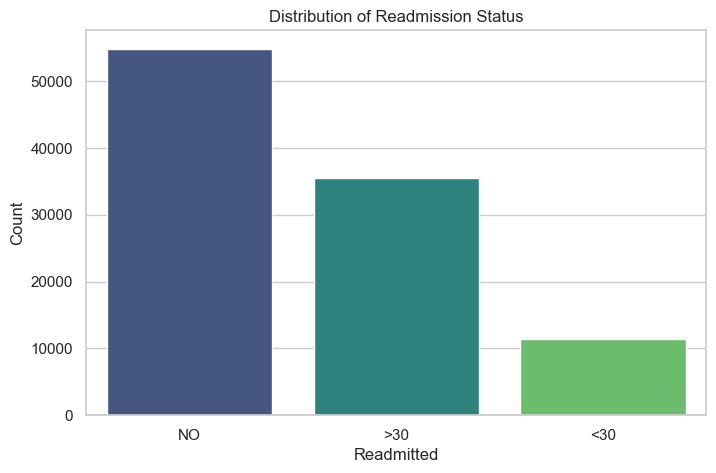

C:\Users\Lokesh Shrestha\AppData\Local\Temp\ipykernel_4100\3703005454.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', order=sorted(df['age'].unique()), palette='magma')


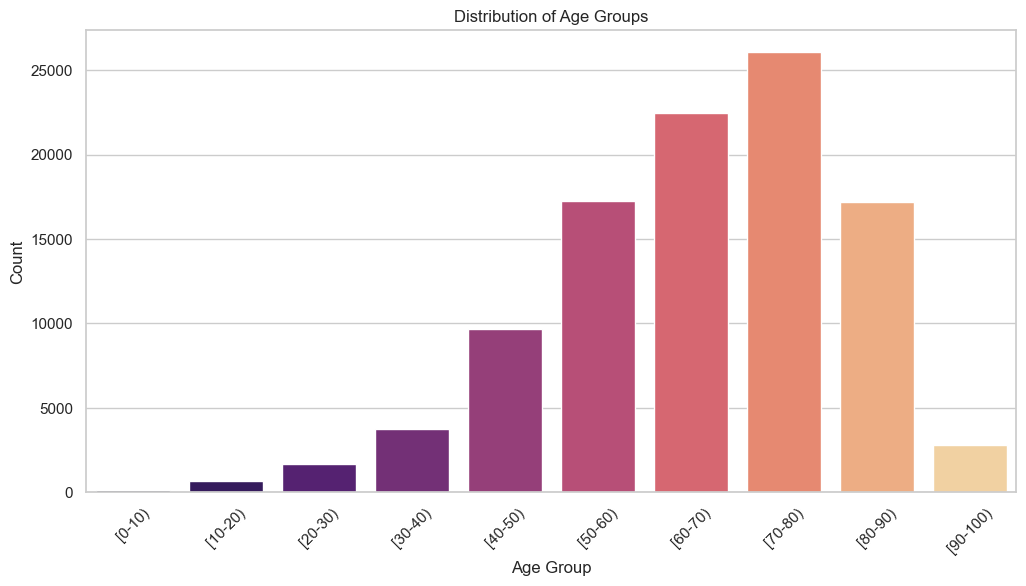

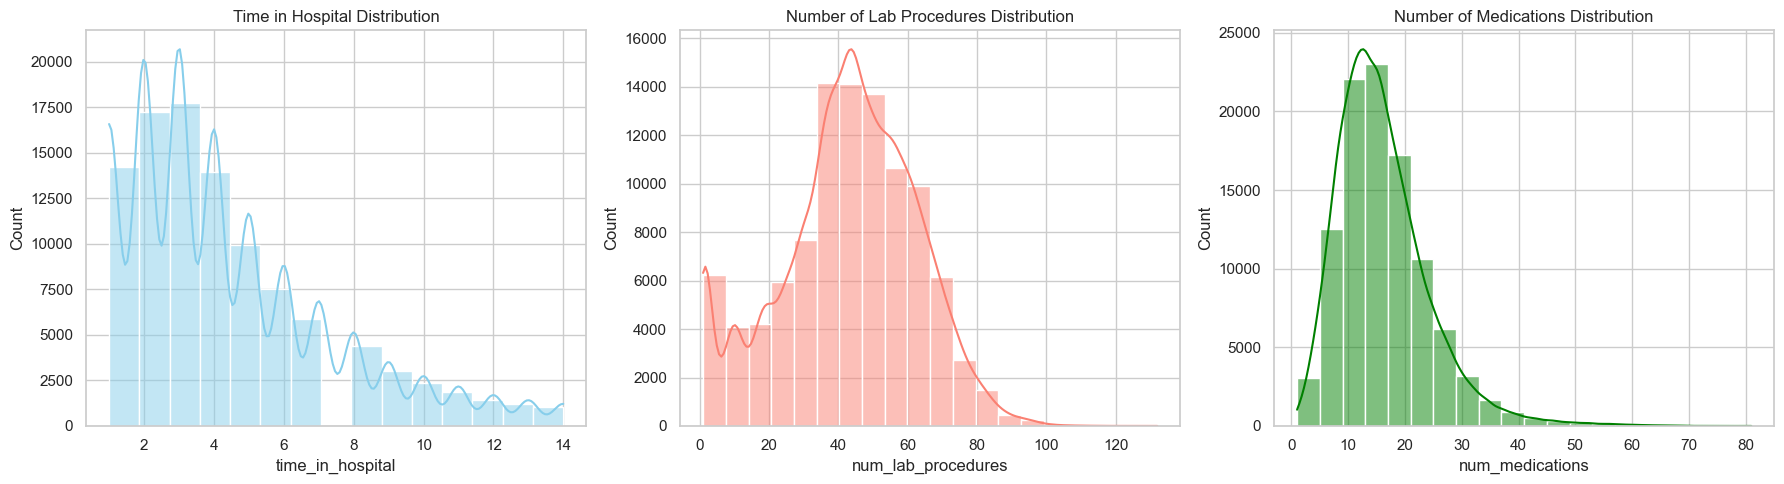

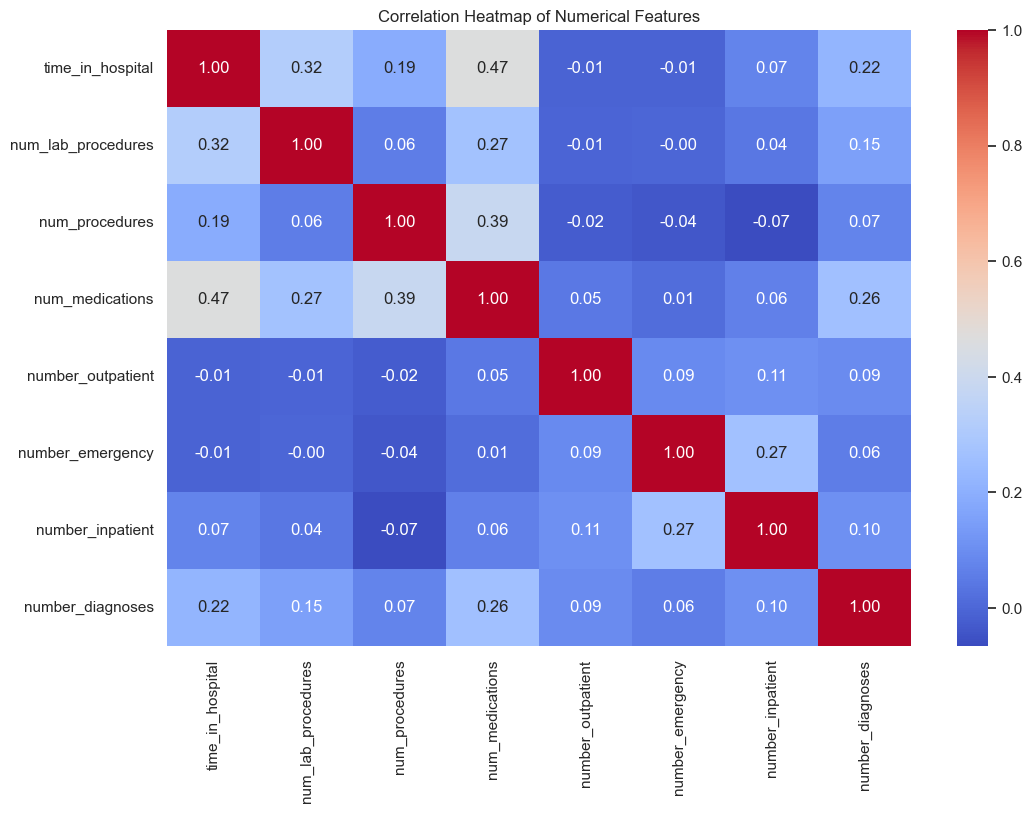

In [19]:
# Data Visualizations - Distribution of Data

# 1. Distribution of the Target Variable (Readmitted)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='readmitted', palette='viridis')
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

# 2. Distribution of Age Groups
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='age', order=sorted(df['age'].unique()), palette='magma')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 3. Distributions of Key Numerical Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['time_in_hospital'], bins=15, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Time in Hospital Distribution')

sns.histplot(df['num_lab_procedures'], bins=20, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Number of Lab Procedures Distribution')

sns.histplot(df['num_medications'], bins=20, ax=axes[2], kde=True, color='green')
axes[2].set_title('Number of Medications Distribution')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap for Numerical Features
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 
                      'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# 1. Clean missing values and drop uninformative columns

df.drop(columns=['encounter_id', 'patient_nbr', 'payer_code', 'weight', 'medical_specialty'], inplace=True)

# 2. Impute missing values (median for numerical, mode for categorical)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Map Target (readmitted) to binary
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' or x == '>30' else 0)

# 4. Encode Categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

y = df['readmitted']
X = df.drop('readmitted', axis=1)
print(f"Preprocessed features shape: {X.shape}")

C:\Users\Lokesh Shrestha\AppData\Local\Temp\ipykernel_4100\3561246156.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Lokesh Shrestha\AppData\Local\Temp\ipykernel_4100\3561246156.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes 

Preprocessed features shape: (101766, 44)


C:\Users\Lokesh Shrestha\AppData\Local\Temp\ipykernel_4100\2257808890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


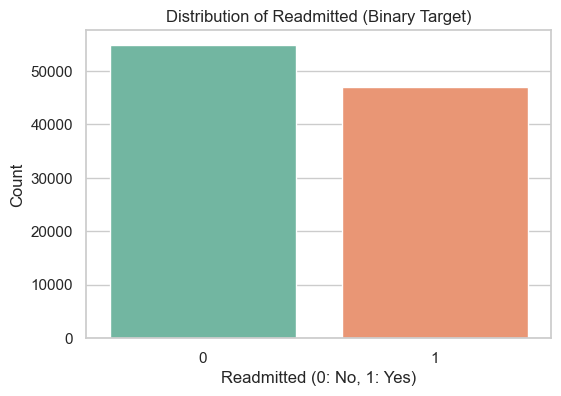

readmitted
0    0.539119
1    0.460881
Name: proportion, dtype: float64


In [21]:
# Visualize the balance of the target variable after mapping to binary
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title('Distribution of Readmitted (Binary Target)')
plt.xlabel('Readmitted (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# Display value counts to see the exact numbers
print(y.value_counts(normalize=True))

In [22]:
# Split the data into Train & Test sets (stratifying to maintain class ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (81412, 44)
Test set size: (20354, 44)


In [23]:
# Scale the features using StandardScaler (crucial step before PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Hyperparameter tuning using RandomizedSearchCV on PCA components
rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

print("Starting Hyperparameter Tuning on PCA components...")
random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=10,
    cv=2,
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print(f"Best parameters found: {random_search.best_params_}")

Starting Hyperparameter Tuning on PCA components...
Fitting 2 folds for each of 10 candidates, totalling 20 fits


KeyboardInterrupt: 

In [ ]:
# Fit model with best parameters and evaluate
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = best_rf.predict(X_test)

print("Random Forest Classifier (on PCA components) Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))